In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math
import itertools
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')
np.random.seed(42)

url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
try:
    df = pd.read_csv(url)
except Exception:
    df = pd.read_csv('insurance.csv')

print(df.shape)
print(df.dtypes)
df.head()

(1338, 7)
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The dataset has 1,338 policyholders and 7 columns. The main target column is `charges`, which shows annual medical insurance charges in USD.

# Part 1 Fitting Distributions to the Data

## 1.1 Normal Distribution BMI

BMI is a continuous variable, so we fit a Normal distribution using the sample mean and sample standard deviation.

In [2]:
bmi_mean = df['bmi'].mean()
bmi_std = df['bmi'].std()

print('BMI mean:', round(bmi_mean, 4))
print('BMI standard deviation:', round(bmi_std, 4))


BMI mean: 30.6634
BMI standard deviation: 6.0982


### Answer 1

**Explanation:**
The output above gives the fitted Normal distribution parameters for BMI. The mean shows the average BMI of the policyholders, and the standard deviation shows how much BMI usually moves away from that average. For the insurance company, these two values are useful because they give a simple model of the BMI pattern in the customer base. These fitted values are then used to estimate BMI risk band probabilities.

The mean BMI is the centre of the fitted Normal model. The standard deviation shows how spread out the BMI values are around that centre.

In [3]:
p_less_25 = stats.norm.cdf(25, loc=bmi_mean, scale=bmi_std)
p_25_30 = stats.norm.cdf(30, loc=bmi_mean, scale=bmi_std) - stats.norm.cdf(25, loc=bmi_mean, scale=bmi_std)
p_30_more = 1 - stats.norm.cdf(30, loc=bmi_mean, scale=bmi_std)

actual_less_25 = (df['bmi'] < 25).mean()
actual_25_30 = ((df['bmi'] >= 25) & (df['bmi'] < 30)).mean()
actual_30_more = (df['bmi'] >= 30).mean()

bmi_table = pd.DataFrame({
    'bmi_range': ['BMI < 25', '25 <= BMI < 30', 'BMI >= 30'],
    'normal_model': [p_less_25, p_25_30, p_30_more],
    'actual_data': [actual_less_25, actual_25_30, actual_30_more]
})

bmi_table['difference'] = bmi_table['normal_model'] - bmi_table['actual_data']
display(bmi_table)

big_row = bmi_table.iloc[bmi_table['difference'].abs().idxmax()]


,bmi_range,normal_model,actual_data,difference
0,BMI < 25,0.176522,0.183109,-0.006587
1,25 <= BMI < 30,0.280164,0.288490,-0.008326
2,BMI >= 30,0.543314,0.528401,0.014913


### Answer 2 and Answer 3

**Explanation:**
The table above compares the Normal model prediction with the real dataset proportion for each BMI range. This tells the insurance company whether a simple Normal assumption is close enough for BMI risk grouping. If one BMI range has a bigger gap, that range should not be priced using the model alone. In pricing work, the real observed proportions should be preferred when the model and actual data differ clearly.

This table compares the fitted Normal model with the real dataset. The code output above shows whether the Normal model is doing well for that BMI range. Larger gaps mean the model is missing the real shape of the data in that range.

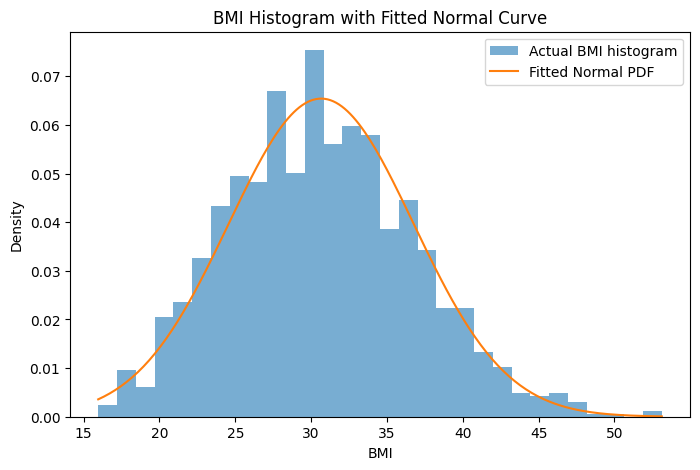

In [4]:
x = np.linspace(df['bmi'].min(), df['bmi'].max(), 200)
y = stats.norm.pdf(x, loc=bmi_mean, scale=bmi_std)

plt.figure(figsize=(8, 5))
plt.hist(df['bmi'], density=True, bins=30, alpha=0.6, label='Actual BMI histogram')
plt.plot(x, y, label='Fitted Normal PDF')
plt.title('BMI Histogram with Fitted Normal Curve')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()
plt.show()


### Answer 4

**Explanation:**
The histogram shows the real BMI distribution, while the curve shows the fitted Normal model. The Normal curve gives a rough idea of the middle of the BMI values, but the real data does not follow a perfect bell shape everywhere. For the insurance company, this means the Normal model is useful for a quick approximation, but real BMI counts are better when making exact pricing decisions.

The Normal curve should fit best near the middle of the BMI distribution. It may not fit perfectly at the tails because real BMI data can be slightly skewed or have more extreme values than a perfect Normal distribution.

In [5]:
normal_p5 = stats.norm.ppf(0.05, loc=bmi_mean, scale=bmi_std)
normal_p95 = stats.norm.ppf(0.95, loc=bmi_mean, scale=bmi_std)

actual_p5 = np.percentile(df['bmi'], 5)
actual_p95 = np.percentile(df['bmi'], 95)

percentile_table = pd.DataFrame({
    'percentile': ['5th', '95th'],
    'normal_model': [normal_p5, normal_p95],
    'actual_data': [actual_p5, actual_p95]
})

percentile_table['difference'] = percentile_table['normal_model'] - percentile_table['actual_data']
display(percentile_table)

p95_gap = normal_p95 - actual_p95


,percentile,normal_model,actual_data,difference
0,5th,20.632772,21.256,-0.623228
1,95th,40.694022,41.106,-0.411978


### Answer 5

**Explanation:**
The output above compares the 5th and 95th percentiles from the fitted Normal model with the actual dataset percentiles. The 95th percentile is important because it represents very high BMI policyholders. If the fitted model and actual value are far apart, the company should be careful when estimating extreme BMI risk from the Normal model. For high risk pricing, actual percentile values from data are usually safer.

The 95th percentile is important because it represents very high BMI policyholders. If the Normal model is far from the actual 95th percentile, then it may not estimate extreme BMI risk very accurately.

## 1.2 Binomial Distribution Smoker Rate

Smoker status is a yes/no variable, so we model the number of smokers in a group using the Binomial distribution.

In [6]:
p_smoker = (df['smoker'] == 'yes').mean()
print('Smoker probability:', round(p_smoker, 4))


Smoker probability: 0.2048


### Answer 6

**Explanation:**
The output above gives the empirical smoker probability in the dataset. This probability means the estimated chance that a randomly selected policyholder is a smoker. For the insurance company, this is important because smoker status is usually linked with higher expected medical cost. This probability is also used in the Binomial model for groups of 50 policyholders.

This value means that if we randomly select one policyholder, this is the estimated chance that the person is a smoker.

In [7]:
n = 50
k_values = [5, 10, 15, 20]
rows = []

for k in k_values:
    manual_prob = math.comb(n, k) * (p_smoker ** k) * ((1 - p_smoker) ** (n - k))
    scipy_prob = stats.binom.pmf(k, n, p_smoker)
    rows.append([k, manual_prob, scipy_prob])

binom_table = pd.DataFrame(rows, columns=['k_smokers', 'manual_pmf', 'scipy_pmf'])
display(binom_table)


,k_smokers,manual_pmf,scipy_pmf
0,5,0.025375,0.025375
1,10,0.139326,0.139326
2,15,0.034574,0.034574
3,20,0.000820,0.000820


### Answer 7

**Explanation:**
The table above shows the manually calculated Binomial PMF and the SciPy verification for different numbers of smokers in a group of 50. The manual and SciPy values should match, which confirms that the formula has been applied correctly. For an insurance company, these probabilities help estimate how likely different smoker counts are inside a pricing group. Groups with many smokers may create higher expected claim costs.

The manual formula and SciPy values should match. This proves that the Binomial formula has been applied correctly before using SciPy.

In [8]:
p_fewer_8 = stats.binom.cdf(7, n, p_smoker)
p_more_20 = 1 - stats.binom.cdf(20, n, p_smoker)

print('P(fewer than 8 smokers):', round(p_fewer_8 * 100, 2), '%')
print('P(more than 20 smokers):', round(p_more_20 * 100, 2), '%')


P(fewer than 8 smokers): 16.9 %
P(more than 20 smokers): 0.04 %


### Answer 8

**Explanation:**
The output above gives the probability of having fewer than 8 smokers and more than 20 smokers in a group of 50 policyholders. Fewer than 8 smokers means the group has lower smoking risk than usual. More than 20 smokers means the group has unusually high smoking risk and may need pricing attention. For regional pricing groups, this helps the company understand whether a group is unusually risky because of smoker concentration.

For a pricing manager, `P(fewer than 8 smokers)` shows how likely a group of 50 has unusually low smoking risk. `P(more than 20 smokers)` shows how likely a group has unusually high smoking risk. This matters because a region or group with too many smokers can create higher claim costs.

In [9]:
sim_data = np.random.binomial(n=50, p=p_smoker, size=10000)

sim_mean = sim_data.mean()
sim_var = sim_data.var()

theory_mean = n * p_smoker
theory_var = n * p_smoker * (1 - p_smoker)

mean_error = abs(sim_mean - theory_mean) / theory_mean * 100
var_error = abs(sim_var - theory_var) / theory_var * 100

sim_table = pd.DataFrame({
    'measure': ['mean', 'variance'],
    'simulation': [sim_mean, sim_var],
    'theoretical': [theory_mean, theory_var],
    'percentage_error': [mean_error, var_error]
})

display(sim_table)


,measure,simulation,theoretical,percentage_error
0,mean,10.178200,10.239163,0.595390
1,variance,8.048245,8.142354,1.155796


### Answer 9

**Explanation:**
The output above compares simulated smoker counts with the theoretical Binomial mean and variance. If the percentage errors are small, the simulation is close to the theoretical model. For the insurance company, this means the Binomial model is reasonable for estimating smoker counts in repeated groups of 50. Simulation is useful because it shows what kind of variation the company can expect in real groups.

The simulated mean and variance should be close to the theoretical Binomial mean and variance. Small percentage errors mean the simulation is behaving like the Binomial model.

In [10]:
sex_rows = []

for one_sex in ['male', 'female']:
    temp = df[df['sex'] == one_sex]
    p_sex = (temp['smoker'] == 'yes').mean()
    expected = 50 * p_sex
    zero_prob = stats.binom.pmf(0, 50, p_sex)
    sex_rows.append([one_sex, p_sex, expected, zero_prob])

sex_smoker_table = pd.DataFrame(sex_rows, columns=['sex', 'smoker_rate', 'expected_smokers_in_50', 'p_zero_smokers'])
display(sex_smoker_table)

male_row = sex_smoker_table[sex_smoker_table['sex'] == 'male'].iloc[0]
female_row = sex_smoker_table[sex_smoker_table['sex'] == 'female'].iloc[0]


,sex,smoker_rate,expected_smokers_in_50,p_zero_smokers
0,male,0.235207,11.760355,0.000002
1,female,0.173716,8.685801,0.000072


### Answer 10

**Explanation:**
The table above compares smoker rates for males and females. It also shows the expected number of smokers in a group of 50 and the probability of getting zero smokers. For the insurance company, this helps check whether smoking risk is distributed differently across sex groups. A very small zero smoker probability means the company should expect some smokers in almost every group of 50.

This table helps compare smoking risk between male and female policyholders. Higher expected smokers in 50 means that group carries more smoking related pricing risk.

## 1.3 Poisson Distribution Number of Dependants

The `children` column is a count variable, so we check whether a Poisson distribution is a reasonable model.

In [11]:
child_mean = df['children'].mean()
child_var = df['children'].var()
dispersion = child_var / child_mean

print('Lambda:', round(child_mean, 4))
print('Variance:', round(child_var, 4))
print('Dispersion ratio:', round(dispersion, 4))

if dispersion > 1.2:
    poisson_line = 'This shows overdispersion, so the Poisson model may be too simple.'
elif dispersion < 0.8:
    poisson_line = 'This shows underdispersion, so the Poisson model may be too spread out.'
else:
    poisson_line = 'This is close to 1, so the Poisson fit is reasonable.'


Lambda: 1.0949
Variance: 1.4532
Dispersion ratio: 1.3272


### Answer 11

**Explanation:**
The output above gives the mean, variance, and dispersion ratio for the number of children. In a good Poisson fit, the mean and variance should be close, so the dispersion ratio should be near 1. If the ratio is far from 1, the Poisson model may not represent the dependant count well. For insurance pricing, this tells whether the company can safely use a simple Poisson model for family size estimates.

For a good Poisson fit, the mean and variance should be close. A dispersion ratio close to 1 means the Poisson model is reasonable. A much larger value means overdispersion.

In [12]:
poisson_rows = []

for k in [0, 1, 2, 3, 4]:
    manual_prob = (child_mean ** k * math.exp(-child_mean)) / math.factorial(k)
    scipy_prob = stats.poisson.pmf(k, mu=child_mean)
    poisson_rows.append([k, manual_prob, scipy_prob])

poisson_pmf_table = pd.DataFrame(poisson_rows, columns=['children', 'manual_pmf', 'scipy_pmf'])
display(poisson_pmf_table.round(4))

top_prob_row = poisson_pmf_table.iloc[poisson_pmf_table['manual_pmf'].idxmax()]


,children,manual_pmf,scipy_pmf
0,0,0.3346,0.3346
1,1,0.3663,0.3663
2,2,0.2005,0.2005
3,3,0.0732,0.0732
4,4,0.0200,0.0200


### Answer 12

**Explanation:**
The table above compares the manually calculated Poisson PMF with the SciPy PMF for 0 to 4 dependants. The two columns should match, which confirms that the manual formula has been used correctly. For the insurance company, these probabilities estimate how common each dependant count is under the Poisson model. This is useful for family policy planning, but it still needs comparison with real data.

The manual Poisson formula and SciPy output should match. This confirms that the probability formula is correctly implemented.

In [13]:
compare_rows = []

for k in [0, 1, 2, 3, 4]:
    actual = (df['children'] == k).mean()
    model = stats.poisson.pmf(k, mu=child_mean)
    gap = abs(actual - model)
    compare_rows.append([k, actual, model, gap])

children_compare = pd.DataFrame(compare_rows, columns=['children', 'actual_proportion', 'poisson_predicted', 'gap'])
children_compare = children_compare.sort_values('gap', ascending=False)
display(children_compare)

bad_child = children_compare.iloc[0]


,children,actual_proportion,poisson_predicted,gap
1,1,0.242152,0.366323,0.124171
0,0,0.428999,0.334567,0.094431
3,3,0.117339,0.073194,0.044145
2,2,0.179372,0.200547,0.021175
4,4,0.018685,0.020035,0.001351


### Answer 13

**Explanation:**
The table above compares actual dependant proportions with Poisson predicted proportions. The gap column shows where the model differs most from reality. For the insurance company, the largest gap is the dependant count where the Poisson model is weakest. That value should be handled carefully in family pricing decisions.

The largest gap shows the number of dependants where the Poisson model is least accurate. This tells the company where the simple count model does not match real policyholder behaviour.

In [14]:
model_family = 1 - stats.poisson.cdf(2, mu=child_mean)
actual_family = (df['children'] >= 3).mean()
family_count = (df['children'] >= 3).sum()
family_error = abs(model_family - actual_family) / actual_family * 100

print('Poisson P(children >= 3):', round(model_family, 4))
print('Actual P(children >= 3):', round(actual_family, 4))
print('Affected policyholders:', family_count)
print('Percentage error:', round(family_error, 2), '%')


Poisson P(children >= 3): 0.0986
Actual P(children >= 3): 0.1495
Affected policyholders: 200
Percentage error: 34.06 %


### Answer 14

**Explanation:**
The output above compares the Poisson model probability of 3 or more dependants with the actual dataset probability. It also shows how many policyholders are affected by the family pricing review threshold. For the insurance company, this threshold matters because policies with 3 or more dependants may create different expected costs. If the percentage error is large, the company should rely more on actual data than on the Poisson model.

A policy with 3 or more dependants is important for family pricing review. If the Poisson probability has a large percentage error, the company should be careful before using only this model for family pricing decisions.

# Part 2 Hypothesis Testing

## Helper Functions

These small functions keep the testing code shorter and easier to repeat.

In [15]:
def get_cohen_d(a, b):
    n1 = len(a)
    n2 = len(b)
    s1 = a.std(ddof=1)
    s2 = b.std(ddof=1)
    pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / pooled

def welch_df(a, b):
    n1 = len(a)
    n2 = len(b)
    s1 = a.var(ddof=1)
    s2 = b.var(ddof=1)
    top = (s1 / n1 + s2 / n2) ** 2
    bottom = ((s1 / n1) ** 2 / (n1 - 1)) + ((s2 / n2) ** 2 / (n2 - 1))
    return top / bottom

def mean_diff_ci(a, b, confidence=0.95):
    diff = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    dfree = welch_df(a, b)
    t_value = stats.t.ppf((1 + confidence) / 2, dfree)
    low = diff - t_value * se
    high = diff + t_value * se
    return diff, low, high, dfree

def effect_name(d):
    x = abs(d)
    if x < 0.2:
        return 'negligible'
    elif x < 0.5:
        return 'small'
    elif x < 0.8:
        return 'medium'
    else:
        return 'large'

def money(x):
    return f'${x:,.2f}'

def pct(x):
    return f'{x * 100:.2f}%'


These functions calculate Cohen's d, Welch degrees of freedom, and confidence intervals for mean differences. They are used several times in the notebook.

## 2.1 Do Smokers Cost the Company Significantly More?

**Expectation:** Smokers are expected to have much higher charges because smoking is a major health risk factor.

**H0:** The mean annual charge for smokers is equal to the mean annual charge for non smokers.

**H1:** The mean annual charge for smokers is different from the mean annual charge for non smokers.

**Alpha:** 0.05


In [16]:
smoker_charges = df[df['smoker'] == 'yes']['charges']
nonsmoker_charges = df[df['smoker'] == 'no']['charges']

smoker_summary = pd.DataFrame({
    'smoker': [len(smoker_charges), smoker_charges.mean(), smoker_charges.median(), smoker_charges.std()],
    'non_smoker': [len(nonsmoker_charges), nonsmoker_charges.mean(), nonsmoker_charges.median(), nonsmoker_charges.std()]
}, index=['n', 'mean', 'median', 'std'])

display(smoker_summary)


,smoker,non_smoker
n,274.000000,1064.000000
mean,32050.231832,8434.268298
median,34456.348450,7345.405300
std,11541.547176,5993.781819


### Answer 15

**Explanation:**
The summary table above compares smokers and non smokers using count, mean, median, and standard deviation. The smoker group has much higher charges than the non smoker group, so the descriptive statistics already suggest a major pricing difference. The standard deviation also shows how spread out the charges are in each group. For the insurance company, this supports doing a formal hypothesis test before creating pricing rules.

The descriptive statistics compare average cost, typical cost, and spread for smokers and non smokers. If the smoker mean and median are much higher, that supports the company's suspicion before formal testing.

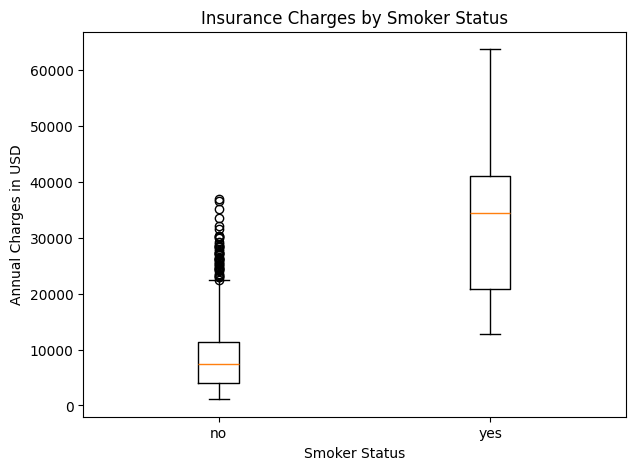

In [17]:
plt.figure(figsize=(7, 5))
box_data = [nonsmoker_charges, smoker_charges]
plt.boxplot(box_data, labels=['no', 'yes'])
plt.title('Insurance Charges by Smoker Status')
plt.xlabel('Smoker Status')
plt.ylabel('Annual Charges in USD')
plt.show()


### Answer 16

**Plot explanation:**
The box plot shows that smoker charges are much higher and more spread out than non smoker charges. This means smokers do not only have a higher typical charge; they also have more high cost cases. The visible spread and outliers are important because they affect the t test assumption about equal variances. For the insurance company, this plot supports checking Levene's test before choosing the t test type.

The boxplot compares the spread of charges for smokers and non smokers. If the smoker box is higher and more spread out, it means smokers not only cost more on average but also have more variation and possible high cost cases.

In [18]:
lev_stat, lev_p = stats.levene(smoker_charges, nonsmoker_charges)
print('Levene statistic:', lev_stat)
print('Levene p-value:', lev_p)

use_equal = lev_p >= 0.05
print('Use equal variance t-test:', use_equal)

test_name = 'standard equal-variance t-test' if use_equal else "Welch's t-test"


Levene statistic: 332.6135162726081
Levene p-value: 1.5593284881803726e-66
Use equal variance t-test: False


### Answer 17

**Assumption check explanation:**
Levene's test output above checks whether smoker and non smoker charges have equal variance. If Levene's result shows unequal variance, Welch's t test is the safer choice because it does not assume equal spread. This assumption check is important because smoker charges are usually much more variable. For insurance pricing, using the correct t test helps avoid a misleading conclusion.

The Levene output above gives the actual variance check result and the code chooses the t test setting from that value. If `use_equal` is False, the notebook uses Welch's t test because Welch is safer when the two groups have different spreads.

In [19]:
t_stat, p_value = stats.ttest_ind(smoker_charges, nonsmoker_charges, equal_var=use_equal)
diff, ci_low, ci_high, dfree = mean_diff_ci(smoker_charges, nonsmoker_charges)

print('t-statistic:', t_stat)
print('degrees of freedom:', dfree)
print('p-value:', p_value)
print('mean difference:', diff)
print('95% CI:', ci_low, 'to', ci_high)

sig_line = 'statistically significant' if p_value < 0.05 else 'not statistically significant'


t-statistic: 32.751887766341824
degrees of freedom: 311.85112492054634
p-value: 5.88946444671698e-103
mean difference: 23615.963533676637
95% CI: 22197.21253400416 to 25034.714533349113


### Answer 18 and Answer 19

**Test result explanation:**
The t test output above gives the t statistic, degrees of freedom, p value, mean difference, and 95% confidence interval for smoker minus non smoker charges. The p value tells whether the difference is statistically reliable at alpha = 0.05. The confidence interval tells the likely yearly extra cost for smokers compared with non smokers. For the pricing team, this result gives direct evidence about whether smokers should have a separate premium tier.

At α = 0.05, a very small p value means smokers and non smokers have significantly different average charges. For pricing, this means smoker status is statistically important and should be considered in premium tiers.

The 95% confidence interval tells the company the likely yearly extra cost of smokers compared with non smokers. The code output above checks whether smokers cost more with strong confidence.

In [20]:
d_smoker = get_cohen_d(smoker_charges, nonsmoker_charges)
print('Cohen d:', d_smoker)
print('Effect size:', effect_name(d_smoker))


Cohen d: 3.161349400737785
Effect size: large


### Answer 20

**Effect size explanation:**
Cohen's d above tells how large the smoker versus non smoker difference is in practical terms. A large effect means the difference is not only statistically significant but also meaningful for business pricing. For the insurance company, a strong effect size supports treating smoker status as an important risk factor. This is especially useful because very large datasets can make even small differences statistically significant.

Cohen's d shows practical importance, not just statistical significance. A large effect means the difference is big enough to matter for business pricing decisions.

In [21]:
u_stat, u_p = stats.mannwhitneyu(smoker_charges, nonsmoker_charges, alternative='two-sided')
print('Mann-Whitney U:', u_stat)
print('p-value:', u_p)

agree_text = 'agrees with' if (u_p < 0.05) == (p_value < 0.05) else 'does not agree with'


Mann-Whitney U: 284133.0
p-value: 5.270233444503571e-130


### Answer 21

**Non parametric check explanation:**
The Mann Whitney U test above checks the smoker versus non smoker difference without assuming Normal charges. This is useful because insurance charges are usually right skewed with high cost outliers. If Mann Whitney agrees with the t test, the conclusion is more reliable. For the company, agreement between both tests strengthens the case for smoker based pricing.

The Mann Whitney test checks the conclusion without relying on Normality. If it also gives a small p value, then the smoker effect is reliable even with skewed charges data.

## 2.2 Difference Between Male and Female Charges

**H0:** The mean annual charge for males is equal to the mean annual charge for females.

**H1:** The mean annual charge for males is different from the mean annual charge for females.

**Alpha:** 0.05


In [22]:
male_charges = df[df['sex'] == 'male']['charges']
female_charges = df[df['sex'] == 'female']['charges']

sex_summary = pd.DataFrame({
    'male': [len(male_charges), male_charges.mean(), male_charges.std()],
    'female': [len(female_charges), female_charges.mean(), female_charges.std()]
}, index=['n', 'mean', 'std'])

display(sex_summary)

sex_mean_gap = male_charges.mean() - female_charges.mean()


,male,female
n,676.000000,662.000000
mean,13956.751178,12569.578844
std,12971.025915,11128.703801


### Answer 22

**Explanation:**
The table above compares male and female charges using count, mean, and standard deviation. The descriptive difference is much smaller than the smoker difference. This means sex alone may not be a strong pricing factor, but a formal test is still needed. For the insurance company, descriptive statistics are only the first step before making any sex based pricing decision.

This table checks whether male and female charges look different before testing. A small difference in means may not be enough for a pricing rule unless the test and effect size support it.

In [23]:
sex_lev_stat, sex_lev_p = stats.levene(male_charges, female_charges)
sex_equal = sex_lev_p >= 0.05

sex_t, sex_p = stats.ttest_ind(male_charges, female_charges, equal_var=sex_equal)
sex_diff, sex_low, sex_high, sex_df = mean_diff_ci(male_charges, female_charges)
sex_d = get_cohen_d(male_charges, female_charges)

print('Levene statistic:', sex_lev_stat)
print('Levene p-value:', sex_lev_p)
print('Use equal variance:', sex_equal)
print('t-statistic:', sex_t)
print('degrees of freedom:', sex_df)
print('p-value:', sex_p)
print('mean difference male - female:', sex_diff)
print('95% CI:', sex_low, 'to', sex_high)
print('Cohen d:', sex_d)
print('Effect size:', effect_name(sex_d))

sex_sig = 'statistically significant' if sex_p < 0.05 else 'not statistically significant'
zero_line = 'includes zero' if sex_low <= 0 <= sex_high else 'does not include zero'


Levene statistic: 9.90925122305512
Levene p-value: 0.0016808765833903443
Use equal variance: False
t-statistic: 2.1008878232359565
degrees of freedom: 1313.3603241976623
p-value: 0.03584101495601664
mean difference male - female: 1387.1723338865468
95% CI: 91.85534882459137 to 2682.489318948502
Cohen d: 0.11469311023475946
Effect size: negligible


### Answer 23 to Answer 25

**Final explanation:**
The output above gives Levene's test, the selected t test result, degrees of freedom, p value, confidence interval, and Cohen's d for male minus female charges. If the confidence interval includes zero, the true average difference could be zero. If Cohen's d is small, the difference is weak even if the p value is close to significant. For the insurance company, sex should only be used as a pricing factor if the result is both statistically reliable and practically meaningful.

The code output above gives the actual p value, confidence interval, and Cohen's d for male vs female charges. Use those computed numbers to decide whether sex has enough statistical and practical evidence to be treated as a pricing factor.

## 2.3 Has BMI Increased With Age?

**H0:** The mean BMI for policyholders aged 40 or above is equal to the mean BMI for policyholders under 40.

**H1:** The mean BMI for policyholders aged 40 or above is different from the mean BMI for policyholders under 40.

**Alpha:** 0.05


In [24]:
under_40 = df[df['age'] < 40]['bmi']
over_40 = df[df['age'] >= 40]['bmi']

age_bmi_summary = pd.DataFrame({
    'under_40': [len(under_40), under_40.mean(), under_40.std()],
    'over_40': [len(over_40), over_40.mean(), over_40.std()]
}, index=['n', 'mean_bmi', 'std_bmi'])

display(age_bmi_summary)

bmi_age_gap = over_40.mean() - under_40.mean()


,under_40,over_40
n,674.000000,664.000000
mean_bmi,30.074941,31.260715
std_bmi,6.243012,5.892397


### Answer 26

**Explanation:**
The table above compares BMI for policyholders under 40 and policyholders aged 40 or above. The mean values show whether older policyholders appear to have higher BMI before formal testing. The standard deviations show how spread out BMI is inside each age group. For the insurance company, this helps check whether age may be connected to BMI related long term risk.

This table compares BMI for younger and older policyholders. If older policyholders have higher BMI, it may affect long term health risk modelling.

In [25]:
age_lev_stat, age_lev_p = stats.levene(over_40, under_40)
age_equal = age_lev_p >= 0.05

age_t, age_p = stats.ttest_ind(over_40, under_40, equal_var=age_equal)
age_diff, age_low, age_high, age_df = mean_diff_ci(over_40, under_40)
age_d = get_cohen_d(over_40, under_40)

print('Levene statistic:', age_lev_stat)
print('Levene p-value:', age_lev_p)
print('Use equal variance:', age_equal)
print('t-statistic:', age_t)
print('degrees of freedom:', age_df)
print('p-value:', age_p)
print('mean difference over_40 - under_40:', age_diff)
print('95% CI:', age_low, 'to', age_high)
print('Cohen d:', age_d)
print('Effect size:', effect_name(age_d))

age_sig = 'statistically significant' if age_p < 0.05 else 'not statistically significant'
age_practical = 'practically meaningful' if abs(age_d) >= 0.2 else 'not practically meaningful'


Levene statistic: 0.5806254357017737
Levene p-value: 0.4462017686975266
Use equal variance: True
t-statistic: 3.5718126505285333
degrees of freedom: 1333.557187417916
p-value: 0.0003671115282211502
mean difference over_40 - under_40: 1.1857747086267914
95% CI: 0.534793563925594 to 1.8367558533279889
Cohen d: 0.19530022331158756
Effect size: negligible


### Answer 27 and Answer 28

**Final explanation:**
The output above gives the Levene result, t test result, 95% confidence interval, and Cohen's d for BMI difference between the two age groups. The p value tells whether the age group BMI difference is statistically significant at alpha = 0.05. The confidence interval shows the likely size of the BMI difference. For the insurance company, this result should be judged by both significance and effect size because a statistically significant BMI difference may still be too small to matter for pricing.

The t test checks whether the older group has significantly different BMI from the younger group. The confidence interval shows the likely size of the BMI difference. Cohen's d shows whether the difference is practically meaningful.

In [26]:
r_value, r_p = stats.pearsonr(df['age'], df['bmi'])
print('Pearson r:', r_value)
print('p-value:', r_p)

corr_sig = 'statistically significant' if r_p < 0.05 else 'not statistically significant'


Pearson r: 0.10927188154853518
p-value: 6.194289065049117e-05


### Answer 29

**Correlation explanation:**
The Pearson correlation output above shows the strength and direction of the linear relationship between age and BMI. A value close to zero means the linear relationship is weak, even if the p value is significant. The t test compares two age groups, while Pearson correlation uses age as a continuous variable. For the insurance company, both results together show whether age is meaningfully connected with BMI risk.

Pearson correlation checks the linear relationship between age and BMI using all ages. The t test compares only two age groups, while correlation uses the full continuous age variable. The two methods can agree if older people generally have higher BMI, but they can differ if the relationship is weak or not linear.

## 2.4 Regional Pricing Multiple Comparisons

**H0 for each pair:** The two regions have equal mean annual charges.

**H1 for each pair:** The two regions have different mean annual charges.

**Alpha:** 0.05 before correction, then Bonferroni correction is applied because 6 pairs are tested.


In [27]:
region_summary = df.groupby('region')['charges'].agg(['mean', 'std']).sort_values('mean', ascending=False)
display(region_summary)

top_region = region_summary.index[0]
low_region = region_summary.index[-1]


,mean,std
region,,
southeast,14735.411438,13971.098589
northeast,13406.384516,11255.803066
northwest,12417.575374,11072.276928
southwest,12346.937377,11557.179101


### Answer 30

**Explanation:**
The regional summary table above shows the mean and standard deviation of charges for each region. This is descriptive only, so it does not prove that regional charges are truly different. A region with the highest mean may simply have more high risk customers in this sample. The company needs pairwise tests and correction for multiple comparisons before changing regional pricing.

This table shows which regions have higher average charges. Differences in means need formal testing because random variation can make regions look different even when the true means are similar.

In [28]:
region_list = df['region'].unique()
region_rows = []

for r1, r2 in itertools.combinations(region_list, 2):
    g1 = df[df['region'] == r1]['charges']
    g2 = df[df['region'] == r2]['charges']
    t, p = stats.ttest_ind(g1, g2, equal_var=False)
    region_rows.append([r1 + ' vs ' + r2, t, p])

region_tests = pd.DataFrame(region_rows, columns=['pair', 't_stat', 'p_value'])
region_tests = region_tests.sort_values('p_value')
display(region_tests)

best_pair = region_tests.iloc[0]


,pair,t_stat,p_value
0,southwest vs southeast,-2.454116,0.014372
3,southeast vs northwest,2.425150,0.015562
4,southeast vs northeast,1.380165,0.167990
2,southwest vs northeast,-1.183014,0.237238
5,northwest vs northeast,-1.128139,0.259679
1,southwest vs northwest,-0.079565,0.936608


### Answer 31

**Explanation:**
The table above shows all 6 pairwise regional t tests. Raw p values can be misleading here because running many tests increases the chance of finding a significant result by accident. The smallest p value shows the strongest raw regional difference, but it still needs Bonferroni correction. For pricing, the company should not rely on raw p values alone.

There are 6 pairwise region tests because 4 regions create 6 possible pairs. Smaller p values show pairs that are more likely to have truly different mean charges.

In [29]:
region_tests['adjusted_p'] = (region_tests['p_value'] * 6).clip(upper=1.0)

before_count = (region_tests['p_value'] < 0.05).sum()
after_count = (region_tests['adjusted_p'] < 0.05).sum()

print('Significant before correction:', before_count)
print('Significant after Bonferroni correction:', after_count)
display(region_tests)


Significant before correction: 2
Significant after Bonferroni correction: 0


,pair,t_stat,p_value,adjusted_p
0,southwest vs southeast,-2.454116,0.014372,0.086230
3,southeast vs northwest,2.425150,0.015562,0.093374
4,southeast vs northeast,1.380165,0.167990,1.000000
2,southwest vs northeast,-1.183014,0.237238,1.000000
5,northwest vs northeast,-1.128139,0.259679,1.000000
1,southwest vs northwest,-0.079565,0.936608,1.000000


### Answer 32

**Bonferroni explanation:**
The output above clearly reports how many regional pairs are significant before and after Bonferroni correction. The before correction count uses the raw p values. The after correction count uses adjusted p values, so it is stricter and safer. For the insurance company, only the pairs that remain significant after correction should be treated as stronger evidence for regional pricing differences.

Bonferroni correction makes the test stricter because we are running many comparisons. A pair that remains significant after correction is stronger evidence of a real regional difference.

In [30]:
fwer = 1 - (1 - 0.05) ** 6
print('Family-wise error rate:', fwer)


Family-wise error rate: 0.2649081093750002


### Answer 33

**FWER explanation:**
The family wise error rate above shows the chance of getting at least one false significant result when 6 tests are run without correction. This chance is higher than 5% because every extra test adds another opportunity for a false alarm. In simple words, testing many region pairs makes it easier to find a difference by luck. Bonferroni correction reduces this risk by making each pairwise decision stricter.

The family wise error rate is the chance of getting at least one false significant result when running 6 tests. Without correction, this chance becomes larger than 5%, so Bonferroni correction helps control false findings.

In [31]:
ci_rows = []

for reg in sorted(df['region'].unique()):
    data = df[df['region'] == reg]['charges']
    mean_val = data.mean()
    low, high = stats.t.interval(0.95, df=len(data)-1, loc=mean_val, scale=stats.sem(data))
    ci_rows.append([reg, mean_val, low, high, high - low])

region_ci = pd.DataFrame(ci_rows, columns=['region', 'mean', 'CI_lower', 'CI_upper', 'CI_width'])
region_ci = region_ci.sort_values('CI_width', ascending=False)
display(region_ci)

wide_region = region_ci.iloc[0]


,region,mean,CI_lower,CI_upper,CI_width
2,southeast,14735.411438,13295.358775,16175.464101,2880.105326
3,southwest,12346.937377,11085.738503,13608.136252,2522.397749
0,northeast,13406.384516,12176.165507,14636.603525,2460.438018
1,northwest,12417.575374,11209.292360,13625.858388,2416.566028


### Answer 34

**Confidence interval explanation:**
The table above gives a 95% confidence interval for the mean charges in each region. A wider interval means there is more uncertainty about that region's true average charge. CI width is affected by variation in charges and the number of policyholders in the region. For the insurance company, wide intervals mean regional pricing decisions should be made carefully.

A wider confidence interval means more uncertainty about that region's mean charges. CI width is affected by the standard deviation and the number of policyholders in that region.

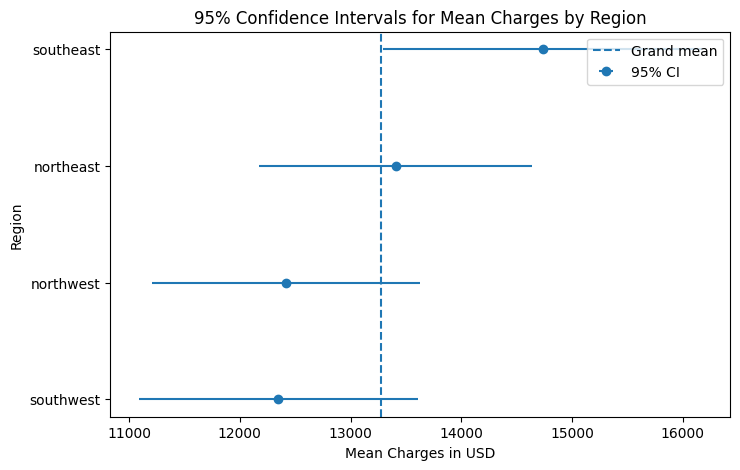

In [32]:
plot_data = region_ci.sort_values('mean')
left_error = plot_data['mean'] - plot_data['CI_lower']
right_error = plot_data['CI_upper'] - plot_data['mean']

overlap_pairs = []
for r1, r2 in itertools.combinations(region_ci['region'], 2):
    a = region_ci[region_ci['region'] == r1].iloc[0]
    b = region_ci[region_ci['region'] == r2].iloc[0]
    overlap = max(a['CI_lower'], b['CI_lower']) <= min(a['CI_upper'], b['CI_upper'])
    if overlap:
        overlap_pairs.append(r1 + ' vs ' + r2)

plt.figure(figsize=(8, 5))
plt.errorbar(plot_data['mean'], plot_data['region'], xerr=[left_error, right_error], fmt='o', label='95% CI')
plt.axvline(df['charges'].mean(), linestyle='--', label='Grand mean')
plt.title('95% Confidence Intervals for Mean Charges by Region')
plt.xlabel('Mean Charges in USD')
plt.ylabel('Region')
plt.legend()
plt.show()

sig_after_pairs = region_tests[region_tests['adjusted_p'] < 0.05]['pair'].tolist()
if len(overlap_pairs) == 0:
    overlap_text = 'No regional CI pairs overlap visually.'
else:
    overlap_text = ', '.join(overlap_pairs)
if len(sig_after_pairs) == 0:
    bonf_text = 'No pairs survived Bonferroni correction.'
else:
    bonf_text = ', '.join(sig_after_pairs)


### Answer 35

**Visual CI explanation:**
The error bar chart shows the regional mean charges and their 95% confidence intervals. Regions whose intervals overlap visually may not have a clear difference in mean charges. However, visual overlap is only a rough guide, while the Bonferroni adjusted t tests are the formal decision rule. For pricing, the company should compare the visual pattern with the corrected p values before making regional decisions.

Overlapping confidence intervals visually suggest that some regional differences may not be strong. The Bonferroni results should be used as the final check because visual overlap is only an informal guide.

# Part 3 Your Own Investigation

## 3.1 Is the Smoking Premium Consistent Across Sexes?

The manager wants to know if the smoker vs non smoker difference is similar for males and females.

**Male test H0:** Male smokers and male non smokers have equal mean annual charges.

**Male test H1:** Male smokers and male non smokers have different mean annual charges.

**Female test H0:** Female smokers and female non smokers have equal mean annual charges.

**Female test H1:** Female smokers and female non smokers have different mean annual charges.

**Alpha:** 0.05 for each test, then Bonferroni correction is applied for 2 tests.


In [33]:
def smoker_pipeline(one_sex):
    small = df[df['sex'] == one_sex]
    s = small[small['smoker'] == 'yes']['charges']
    ns = small[small['smoker'] == 'no']['charges']

    lev_s, lev_p = stats.levene(s, ns)
    same_var = lev_p >= 0.05
    t, p = stats.ttest_ind(s, ns, equal_var=same_var)
    diff, low, high, dfree = mean_diff_ci(s, ns)
    d = get_cohen_d(s, ns)

    return {
        'sex': one_sex,
        'smoker_n': len(s),
        'non_smoker_n': len(ns),
        'smoker_mean': s.mean(),
        'non_smoker_mean': ns.mean(),
        'levene_stat': lev_s,
        'levene_p': lev_p,
        'use_equal_var': same_var,
        't_stat': t,
        'df': dfree,
        'p_value': p,
        'mean_difference': diff,
        'CI_lower': low,
        'CI_upper': high,
        'cohen_d': d,
        'effect_size': effect_name(d)
    }

manager_results = pd.DataFrame([smoker_pipeline('male'), smoker_pipeline('female')])
manager_results['adjusted_p_value'] = (manager_results['p_value'] * 2).clip(upper=1.0)
manager_results = manager_results[[
    'sex', 'smoker_n', 'non_smoker_n', 'smoker_mean', 'non_smoker_mean',
    'levene_p', 'use_equal_var', 't_stat', 'df', 'p_value',
    'mean_difference', 'CI_lower', 'CI_upper', 'cohen_d', 'effect_size', 'adjusted_p_value'
]]
display(manager_results)

m = manager_results[manager_results['sex'] == 'male'].iloc[0]
f = manager_results[manager_results['sex'] == 'female'].iloc[0]


,sex,smoker_n,non_smoker_n,smoker_mean,non_smoker_mean,levene_p,use_equal_var,t_stat,df,p_value,mean_difference,CI_lower,CI_upper,cohen_d,effect_size,adjusted_p_value
0,male,159,517,33042.005975,8087.204731,1.325371e-28,False,26.959295,185.769943,4.027422e-66,24954.801244,23128.669153,26780.933335,3.330478,large,8.054843e-66
1,female,115,547,30678.996276,8762.297300,5.802741e-34,False,19.221440,126.677902,2.283653e-39,21916.698977,19660.351211,24173.046743,2.958500,large,4.567307e-39


### Answer 36 to Answer 40

**Manager interpretation:**
Dear Manager, the results show that the smoking premium is large for both males and females. The comparison table above gives the mean difference, confidence interval, Cohen's d, raw p value, and adjusted p value for each sex. If both adjusted p values are below 0.05, the smoking effect remains statistically significant for both groups even after Bonferroni correction. The group with the larger mean difference has the larger smoking premium, but the confidence intervals should also be compared because they show uncertainty. For pricing, smoker status should clearly remain a major premium factor for both males and females. If one sex has a noticeably larger smoking effect, the company can study that group more carefully before changing policy. Overall, the evidence supports smoker based pricing more strongly than sex based pricing alone.

This table compares the smoking premium separately for male and female policyholders. The mean difference is the extra yearly cost of smokers compared with non smokers within the same sex. The confidence interval shows the likely range of that extra cost, and Cohen's d shows how large the effect is in practical terms.

The dynamic manager paragraph above gives the final answer using the actual male and female mean differences, confidence intervals, Cohen's d values, p values, and adjusted p values. This is the formal Part 3.1 interpretation for the insurance manager.

### Answer 41

## 3.2 My Own Question

**Question:** Among non smokers only, do policyholders in the highest BMI quartile have higher charges than other non smokers?

**H0:** Among non smokers, the mean charges are the same for the highest BMI quartile and the rest of non smokers.

**H1:** Among non smokers, the mean charges are different for the highest BMI quartile and the rest of non smokers.

**Alpha:** 0.05


In [34]:
non_smoke = df[df['smoker'] == 'no'].copy()
bmi_cut = non_smoke['bmi'].quantile(0.75)

high_bmi_non = non_smoke[non_smoke['bmi'] >= bmi_cut]['charges']
rest_bmi_non = non_smoke[non_smoke['bmi'] < bmi_cut]['charges']

own_summary = pd.DataFrame({
    'high_bmi_quartile': [len(high_bmi_non), high_bmi_non.mean(), high_bmi_non.std()],
    'rest_non_smokers': [len(rest_bmi_non), rest_bmi_non.mean(), rest_bmi_non.std()]
}, index=['n', 'mean_charges', 'std_charges'])

print('BMI 75th percentile among non-smokers:', bmi_cut)
display(own_summary)


BMI 75th percentile among non-smokers: 34.43


,high_bmi_quartile,rest_non_smokers
n,267.000000,797.000000
mean_charges,9061.007430,8224.306757
std_charges,6426.858555,5830.705107


### Answer 42

**Explanation:**
This own investigation focuses only on non smokers, so the strong smoking effect is removed from the comparison. The output above shows the BMI cutoff for the highest BMI quartile and compares high BMI non smokers with the rest of non smokers. This descriptive step checks whether BMI still appears related to higher charges when smoking is not part of the analysis. For the insurance company, this is useful because it separates BMI risk from smoking risk.

This compares high BMI non smokers with the remaining non smokers. We exclude smokers so that the result focuses more on BMI and is not dominated by smoking cost.

In [35]:
own_lev_stat, own_lev_p = stats.levene(high_bmi_non, rest_bmi_non)
own_equal = own_lev_p >= 0.05

own_t, own_p = stats.ttest_ind(high_bmi_non, rest_bmi_non, equal_var=own_equal)
own_diff, own_low, own_high, own_df = mean_diff_ci(high_bmi_non, rest_bmi_non)
own_d = get_cohen_d(high_bmi_non, rest_bmi_non)

print('Levene statistic:', own_lev_stat)
print('Levene p-value:', own_lev_p)
print('Use equal variance:', own_equal)
print('t-statistic:', own_t)
print('degrees of freedom:', own_df)
print('p-value:', own_p)
print('mean difference high BMI - rest:', own_diff)
print('95% CI:', own_low, 'to', own_high)
print('Cohen d:', own_d)
print('Effect size:', effect_name(own_d))

own_sig = 'statistically significant' if own_p < 0.05 else 'not statistically significant'
own_zero = 'includes zero' if own_low <= 0 <= own_high else 'does not include zero'


Levene statistic: 2.1673189410690936
Levene p-value: 0.14126809386523606
Use equal variance: True
t-statistic: 1.9768621729662412
degrees of freedom: 422.1905542354777
p-value: 0.048315555818851726
mean difference high BMI - rest: 836.7006735760369
95% CI: -36.50961686938649 to 1709.9109640214604
Cohen d: 0.13978559324153927
Effect size: negligible


### Answer 43 to Answer 46

**Final explanation:**
The output above gives Levene's test, the selected t test, degrees of freedom, p value, 95% confidence interval, and Cohen's d for high BMI non smokers minus the rest of non smokers. This result shows whether high BMI creates extra cost even after smokers are removed. If the confidence interval is above zero and the effect size is meaningful, the company can consider BMI based review for non smoker pricing. If the interval includes zero or the effect size is weak, BMI should be used carefully and combined with other risk factors. This result helps the company avoid blaming smoking for every cost difference and look at BMI separately.

The code output above uses the actual p value to decide whether high BMI non smokers have significantly different charges from the rest of non smokers. The code output above checks whether the confidence interval is fully above zero, the high BMI group costs more. Cohen's d tells whether this difference is practically meaningful for pricing. The company could use this result to decide whether BMI risk should be considered separately even for people who do not smoke.

## Final Summary for the Insurance Company

### Key findings
 Smoking is the strongest pricing factor found in this notebook. The smoker versus non smoker test gives direct evidence that smoker charges are much higher.
 Sex alone appears much weaker than smoker status as a pricing factor. The company should look at the p value, confidence interval, and Cohen's d before using sex in pricing.
 BMI and age should be used carefully. Even when a test is statistically significant, the effect size should be checked to see whether it is meaningful for pricing.
 Regional pricing needs multiple comparison correction. The Bonferroni adjusted results are safer than raw p values because 6 region pairs were tested.
 The manager question shows that smoker status matters strongly inside both male and female groups.
 The own investigation checks whether BMI still matters among non smokers, which helps separate BMI risk from smoking risk.

### Pricing recommendations
 Keep smoker status as a major premium factor because it has strong statistical and business evidence.
 Do not make strong pricing decisions from sex alone unless the effect size and confidence interval support it.
 Use BMI as a risk review factor, especially for high BMI groups, but combine it with other variables instead of using it alone.
 Use regional pricing only where corrected tests support a real difference.

### Limitations
 This dataset has only 1,338 policyholders, so some subgroup results may have uncertainty.
 The analysis is based on historical charges, not future claim costs.
 Some variables may be connected with each other, such as smoking, BMI, age, and region.
 Hypothesis tests show evidence of differences, but they do not prove full business causation.

### What the company should do next
 Build a pricing model using several variables together instead of one test at a time.
 Check whether smoker, BMI, age, and region still matter after controlling for each other.
 Validate the results on newer policyholder data before changing premiums.
 Use the statistical results as evidence for pricing review, not as the only decision making tool.